# Distributions - Basic Discrete and Continuous

This notebook demonstrates the basic distribution API in **probjax**.

All distributions follow a consistent interface:
- `logpdf(x)` / `logpmf(x)` - log probability density/mass function
- `pdf(x)` / `pmf(x)` - probability density/mass function
- `rvs(key, shape)` - random variates
- `sample(key, shape)` - alias for `rvs`
- `mean()`, `var()`, `std()` - moments
- `cdf(x)`, `ppf(q)` - cumulative distribution and its inverse
- `fit(data)` - fit distribution parameters to data (MLE)
- `entropy()`, `median()`, `moment(n)` - additional statistics

In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import probjax.stats as stats

key = jax.random.PRNGKey(0)

## Continuous Distributions

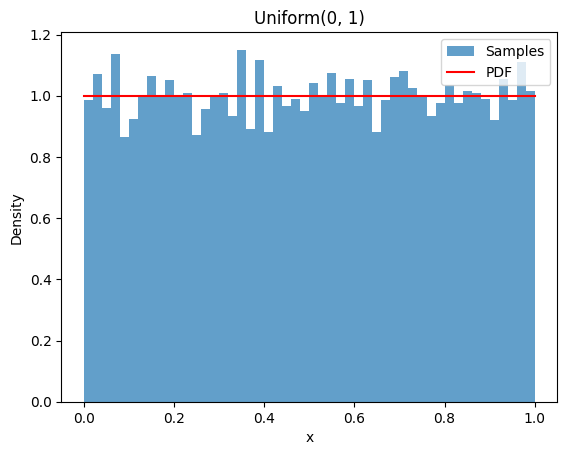

Mean: 0.500, Var: 0.083


In [5]:
# Uniform distribution
key, subkey = jax.random.split(key)
p = stats.uniform(low=0., high=1.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 1, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Uniform(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

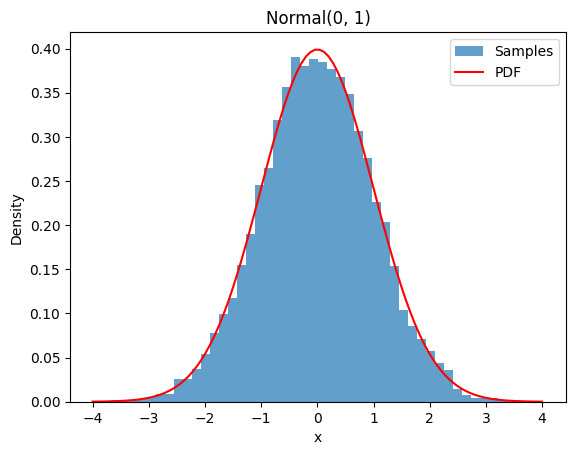

Mean: 0.000, Var: 1.000


In [6]:
# Normal distribution
key, subkey = jax.random.split(key)
p = stats.norm(loc=0., scale=1.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(-4, 4, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Normal(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

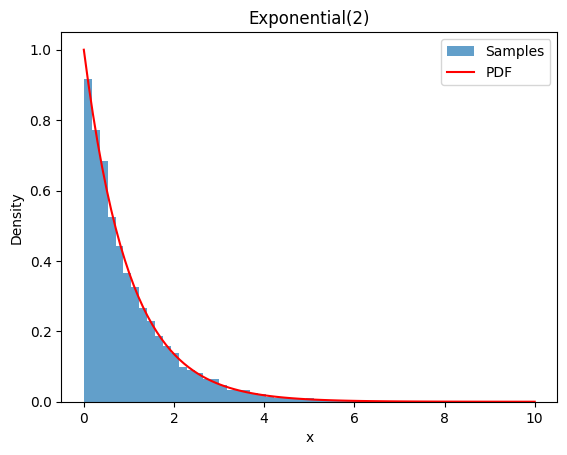

Mean: 1.000, Var: 1.000


In [7]:
# Exponential distribution
key, subkey = jax.random.split(key)
p = stats.expon(scale=2.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 10, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Exponential(2)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

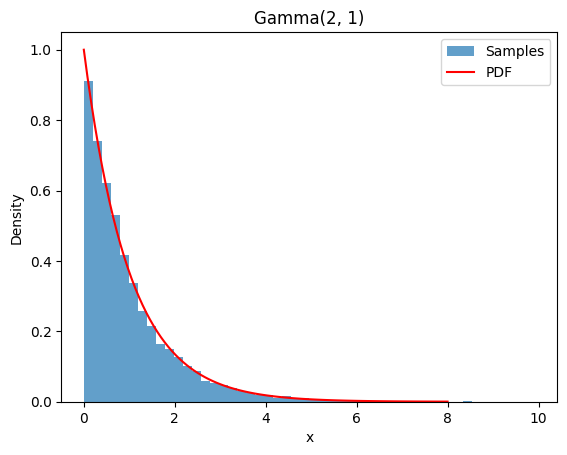

Mean: 1.000, Var: 1.000


In [8]:
# Gamma distribution
key, subkey = jax.random.split(key)
p = stats.gamma(a=2., scale=1.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 8, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gamma(2, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

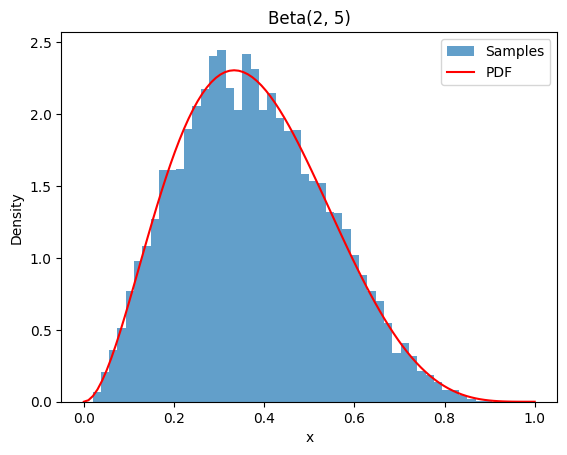

Mean: 0.375, Var: 0.026


In [24]:
# Beta distribution
key, subkey = jax.random.split(key)
p = stats.beta(alpha=3., beta=5.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 1, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Beta(2, 5)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

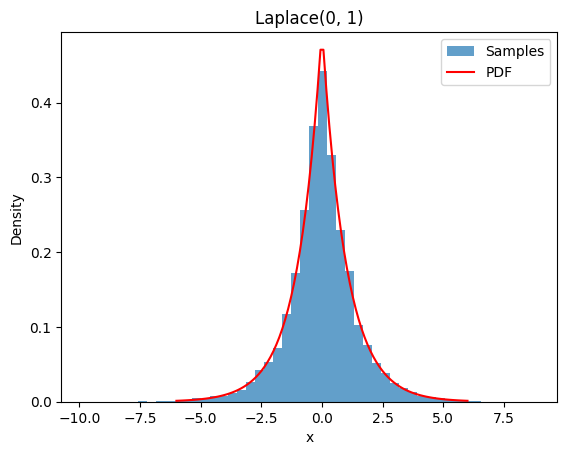

Mean: 0.000, Var: 2.000


In [25]:
# Laplace distribution
key, subkey = jax.random.split(key)
p = stats.laplace(loc=0., scale=1.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(-6, 6, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Laplace(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

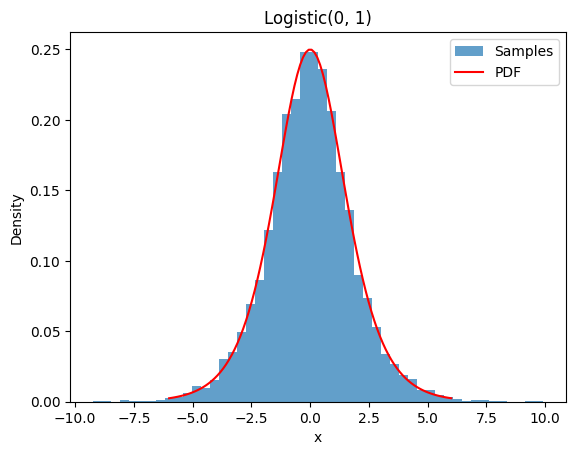

Mean: 0.000, Var: 3.290


In [26]:
# Logistic distribution
key, subkey = jax.random.split(key)
p = stats.logistic(loc=0., scale=1.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(-6, 6, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Logistic(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

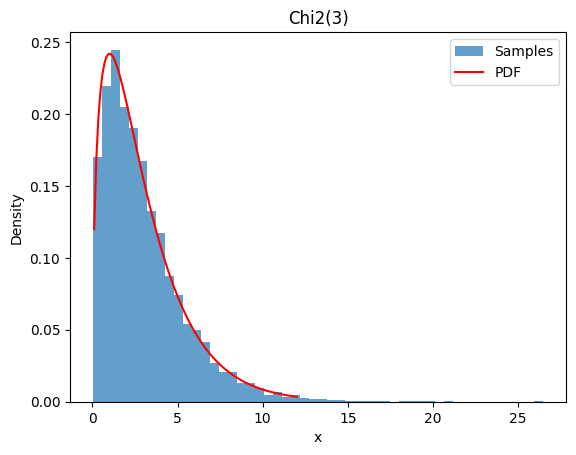

Mean: 3.000, Var: 6.000


In [28]:
# Chi-squared distribution
key, subkey = jax.random.split(key)
p = stats.chi2(df=3.)

samples = p.rvs(subkey, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0.1, 12, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Chi2(3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

## Discrete Distributions

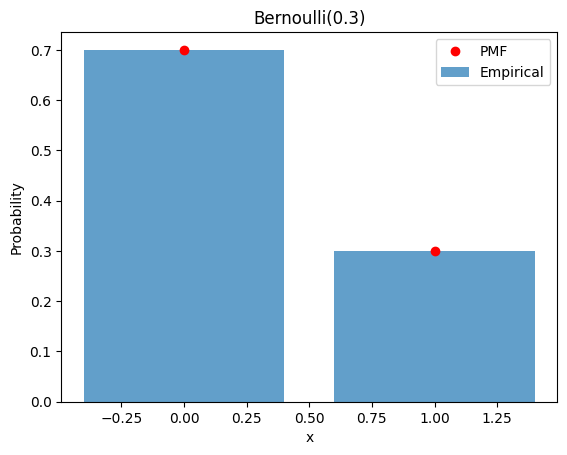

Mean: 0.300, Var: 0.210


In [29]:
# Bernoulli distribution
key, subkey = jax.random.split(key)
p = stats.bernoulli(p=0.3)

samples = p.rvs(subkey, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Bernoulli(0.3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

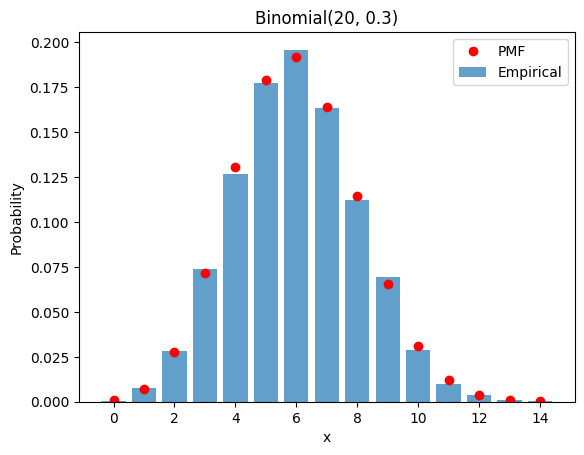

Mean: 6.000, Var: 4.200


In [30]:
# Binomial distribution
key, subkey = jax.random.split(key)
p = stats.binomial(n=20, probs=0.3)

samples = p.rvs(subkey, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Binomial(20, 0.3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

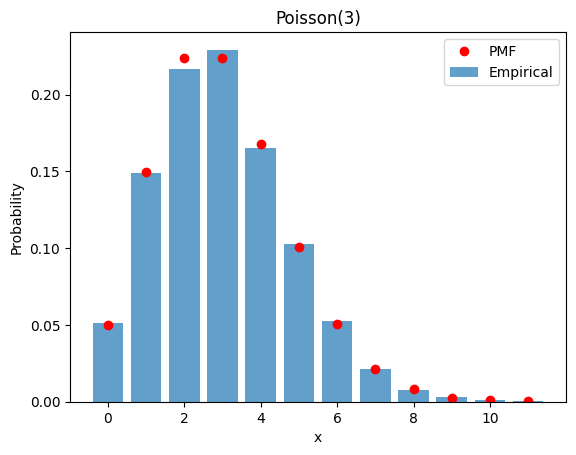

Mean: 3.000, Var: 3.000


In [31]:
# Poisson distribution
key, subkey = jax.random.split(key)
p = stats.poisson(rate=3.)

samples = p.rvs(subkey, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Poisson(3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

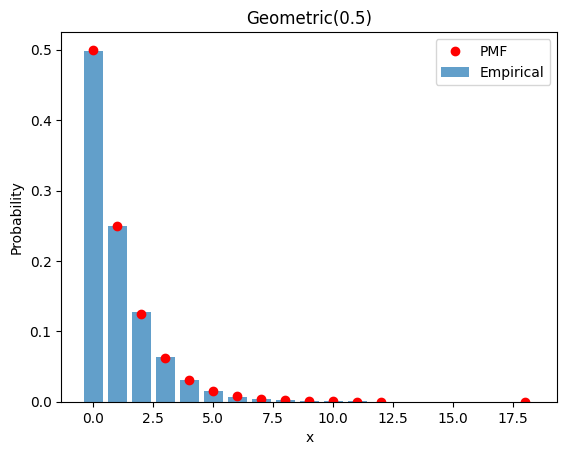

Mean: 1.000, Var: 2.000


In [32]:
# Geometric distribution
key, subkey = jax.random.split(key)
p = stats.geometric(p=0.5)

samples = p.rvs(subkey, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support[:15], counts[:15]/10000, alpha=0.7, label='Empirical')
plt.plot(support[:15], jnp.exp(p.logpmf(support[:15])), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Geometric(0.5)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

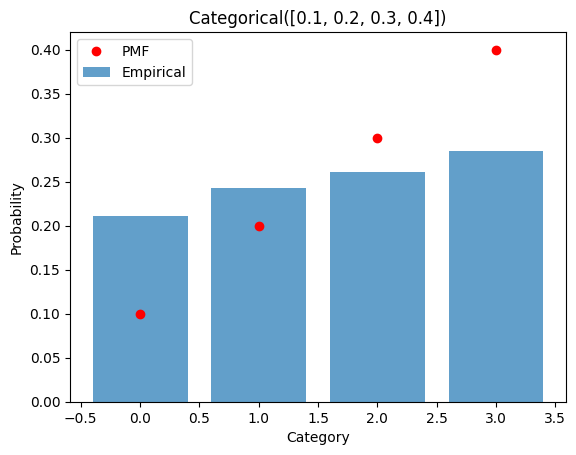

Mean: 2.000, Var: 1.000


In [33]:
# Categorical distribution
key, subkey = jax.random.split(key)
p = stats.categorical(probs=jnp.array([0.1, 0.2, 0.3, 0.4]))

samples = p.rvs(subkey, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('Category')
plt.ylabel('Probability')
plt.title('Categorical([0.1, 0.2, 0.3, 0.4])')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

## Multivariate Distributions

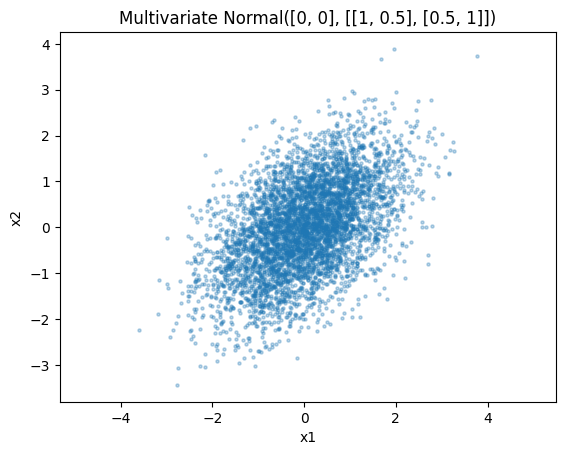

Mean: [0. 0.]
Cov:
[[1.  0.5]
 [0.5 1. ]]


In [18]:
# Multivariate Normal
key, subkey = jax.random.split(key)
mean = jnp.array([0., 0.])
cov = jnp.array([[1., 0.5], [0.5, 1.]])
p = stats.multivariate_normal(loc=mean, cov=cov)

samples = p.rvs(subkey, shape=(5000,))

plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multivariate Normal([0, 0], [[1, 0.5], [0.5, 1]])')
plt.axis('equal')
plt.show()

print(f"Mean: {p.mean()}")
print(f"Cov:\n{p.cov}")

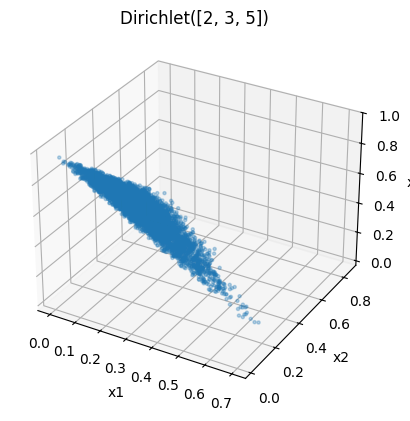

Mean: [0.2 0.3 0.5]


In [19]:
# Dirichlet distribution
key, subkey = jax.random.split(key)
alpha = jnp.array([2., 3., 5.])
p = stats.dirichlet(alpha=alpha)

samples = p.rvs(subkey, shape=(5000,))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], alpha=0.3, s=5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Dirichlet([2, 3, 5])')
plt.show()

print(f"Mean: {p.mean()}")

## Methodology: CDF, PPF, and Survival Functions

Beyond PDF/PMF and sampling, distributions provide:
- `cdf(x)` - cumulative distribution function
- `logcdf(x)` - log of the CDF
- `sf(x)` - survival function (1 - CDF)
- `ppf(q)` - percent-point function (inverse CDF)
- `isf(q)` - inverse survival function

CDF values: [0.15865527 0.5        0.8413447  0.97724986]
SF values:  [0.8413447  0.5        0.15865527 0.02275013]
PPF values: [-1.9599638  0.         1.9599643]


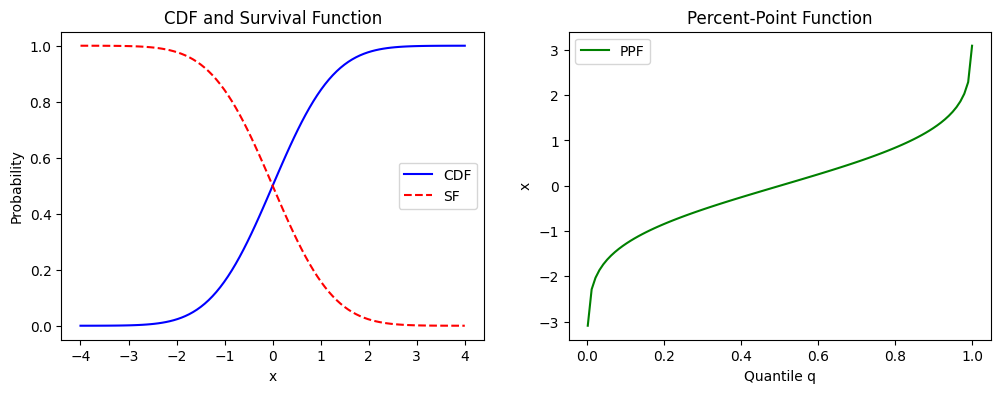

In [20]:
dist = stats.norm(loc=0., scale=1.)

# Evaluate CDF at several points
xs = jnp.array([-1., 0., 1., 2.])
print("CDF values:", dist.cdf(xs))
print("SF values: ", dist.sf(xs))

# Inverse CDF (quantiles)
qs = jnp.array([0.025, 0.5, 0.975])
print("PPF values:", dist.ppf(qs))

# Plot CDF and PPF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

xs = jnp.linspace(-4, 4, 100)
axes[0].plot(xs, dist.cdf(xs), 'b-', label='CDF')
axes[0].plot(xs, dist.sf(xs), 'r--', label='SF')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability')
axes[0].set_title('CDF and Survival Function')
axes[0].legend()

qs = jnp.linspace(0.001, 0.999, 100)
axes[1].plot(qs, dist.ppf(qs), 'g-', label='PPF')
axes[1].set_xlabel('Quantile q')
axes[1].set_ylabel('x')
axes[1].set_title('Percent-Point Function')
axes[1].legend()

plt.show()

## Methodology: Fitting Distributions to Data

The `fit` method performs maximum-likelihood estimation (MLE) on observed data.
It returns the estimated parameters for the distribution family.

Many distributions have closed-form or specialized estimators (e.g., `norm`, `gamma`, `bernoulli`),
while others fall back to numerical optimization.

In [21]:
key, subkey = jax.random.split(key)

# Generate synthetic data from a known distribution
true_dist = stats.norm(loc=5., scale=2.)
data = true_dist.rvs(subkey, shape=(1000,))

# Fit a normal distribution to the data
mu_est, sigma_est = stats.norm.fit(data)
print(f"True params:     mu=5.00, sigma=2.00")
print(f"Estimated params: mu={mu_est:.3f}, sigma={sigma_est:.3f}")

# Fit a gamma distribution to the same data
key, subkey = jax.random.split(key)
true_gamma = stats.gamma(a=3., scale=2.)
data_gamma = true_gamma.rvs(subkey, shape=(1000,))

a_est, scale_est = stats.gamma.fit(data_gamma)
print(f"\nTrue gamma params:     a=3.00, scale=2.00")
print(f"Estimated gamma params: a={a_est:.3f}, scale={scale_est:.3f}")

# Fit a Bernoulli distribution
key, subkey = jax.random.split(key)
true_bern = stats.bernoulli(p=0.7)
data_bern = true_bern.rvs(subkey, shape=(1000,))

p_est = stats.bernoulli.fit(data_bern)
print(f"\nTrue Bernoulli p:     0.70")
print(f"Estimated Bernoulli p: {p_est[0]:.3f}")

True params:     mu=5.00, sigma=2.00
Estimated params: mu=4.939, sigma=2.011

True gamma params:     a=3.00, scale=2.00
Estimated gamma params: a=1.031, scale=1.052

True Bernoulli p:     0.70
Estimated Bernoulli p: 0.699


## Methodology: Moments, Entropy, and Other Statistics

Distributions expose a rich set of analytical statistics:
- `moment(n)` - n-th non-central moment
- `entropy()` - differential (continuous) or Shannon (discrete) entropy
- `median()` - median (default: `ppf(0.5)`)
- `interval(confidence)` - symmetric confidence interval around the median

In [22]:
dist = stats.norm(loc=0., scale=1.)

print("Standard Normal Statistics:")
print(f"  Mean:      {dist.mean():.4f}")
print(f"  Variance:  {dist.var():.4f}")
print(f"  Std:       {dist.std():.4f}")
print(f"  Median:    {dist.median():.4f}")
print(f"  Entropy:   {dist.entropy():.4f}")
print(f"  1st moment: {dist.moment(1):.4f}")
print(f"  2nd moment: {dist.moment(2):.4f}")

# 95% confidence interval
low, high = dist.interval(0.95)
print(f"\n95% confidence interval: [{low:.4f}, {high:.4f}]")

# Higher moments with Gamma (supports arbitrary moments)
gamma_dist = stats.gamma(a=2., scale=1.)
print(f"\nGamma(2, 1) Statistics:")
print(f"  Mean:       {gamma_dist.mean():.4f}")
print(f"  Variance:   {gamma_dist.var():.4f}")
print(f"  Std:        {gamma_dist.std():.4f}")
print(f"  Median:     {gamma_dist.median():.4f}")
print(f"  Entropy:    {gamma_dist.entropy():.4f}")
print(f"  1st moment: {gamma_dist.moment(1):.4f}")
print(f"  2nd moment: {gamma_dist.moment(2):.4f}")
print(f"  3rd moment: {gamma_dist.moment(3):.4f}")
print(f"  4th moment: {gamma_dist.moment(4):.4f}")
print(f"  95% CI:     [{gamma_dist.interval(0.95)[0]:.4f}, {gamma_dist.interval(0.95)[1]:.4f}]")

Standard Normal Statistics:
  Mean:      0.0000
  Variance:  1.0000
  Std:       1.0000
  Median:    0.0000
  Entropy:   1.4189
  1st moment: 0.0000
  2nd moment: 1.0000

95% confidence interval: [-1.9600, 1.9600]

Gamma(2, 1) Statistics:
  Mean:       1.0000
  Variance:   1.0000
  Std:        1.0000
  Median:     0.6931
  Entropy:    1.0000
  1st moment: 1.0000
  2nd moment: 2.0000
  3rd moment: 6.0000
  4th moment: 24.0000
  95% CI:     [0.0253, 3.6889]


## Summary

All distributions in probjax share a consistent API:

- **Initialization**: Create with parameters (e.g., `stats.norm(loc=0, scale=1)`)
- **Log probability**: `logpdf(x)` for continuous, `logpmf(x)` for discrete
- **Sampling**: `rvs(key, shape)` for multiple samples, `sample(key, shape)` for single
- **Moments**: `mean()`, `var()`, `std()` as methods; `moment(n)` for higher-order moments
- **CDF / PPF**: `cdf(x)`, `ppf(q)`, `sf(x)`, `isf(q)`
- **Fitting**: `fit(data)` for MLE parameter estimation
- **Statistics**: `entropy()`, `median()`, `interval(confidence)`

This unified interface makes it easy to swap distributions in models and algorithms.